# Project FORESIGHT — Phase 10: Forecasting Strategy Improvement

Experimental layer on top of **frozen** Phase 8 LightGBM and **frozen** Phase 9 stability analysis.

Priority: hurdle/zero-demand → direct multi-horizon → prediction intervals → small HPO.


## 1. Load artifacts

In [1]:
import os, sys, json
import pandas as pd
from IPython.display import Image, display

BASE_DIR = os.path.abspath(".")
if os.path.basename(BASE_DIR) == "notebooks":
    BASE_DIR = os.path.abspath("..")
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

from src.phase10_common import PHASE10_DIR, FIGURES_DIR, METADATA_PATH, REGISTRY_PATH, PHASE8_TEST
from src.validate_phase10 import run_validation

meta = json.load(open(METADATA_PATH, encoding="utf-8"))
print("Phase 8 frozen", PHASE8_TEST)
print("phase8_unchanged", meta.get("phase8_unchanged"), "phase9_unchanged", meta.get("phase9_unchanged"))
print("decision", meta["decision"]["option"], meta["decision"]["label"])
print(meta["decision"]["statement"])


Phase 8 frozen {'UCI': {'model': 'lightgbm', 'MAE': 17.3447, 'RMSE': 70.8952, 'sMAPE': 82.8734, 'WAPE': 79.471}, 'SYNTHETIC': {'model': 'lightgbm', 'MAE': 2.8156, 'RMSE': 5.1469, 'sMAPE': 113.6813, 'WAPE': 38.8923}}
phase8_unchanged True phase9_unchanged True
decision A Major improvement
Structural models substantially outperform frozen LightGBM.


## 2. Hurdle vs Phase 8

source_dataset  skipped                                                                                                                                                                       reason  best_threshold  n_matched  phase8_WAPE  hurdle_WAPE  phase8_MAE  hurdle_MAE  phase8_sMAPE  hurdle_sMAPE  phase8_bias  hurdle_bias  phase8_zero_mae  hurdle_zero_mae  phase8_nonzero_mae  hurdle_nonzero_mae  phase8_zero_pos_rate  hurdle_zero_pos_rate  wape_improvement_pct
           UCI     True Train zero-demand share=0.00% < 5%. Hurdle is for intermittent demand; UCI rows are predominantly positive-demand invoice days (missing days are absent, not coded as zero).             NaN        NaN          NaN          NaN         NaN         NaN           NaN           NaN          NaN          NaN              NaN              NaN                 NaN                 NaN                   NaN                   NaN                   NaN
     SYNTHETIC    False                                         

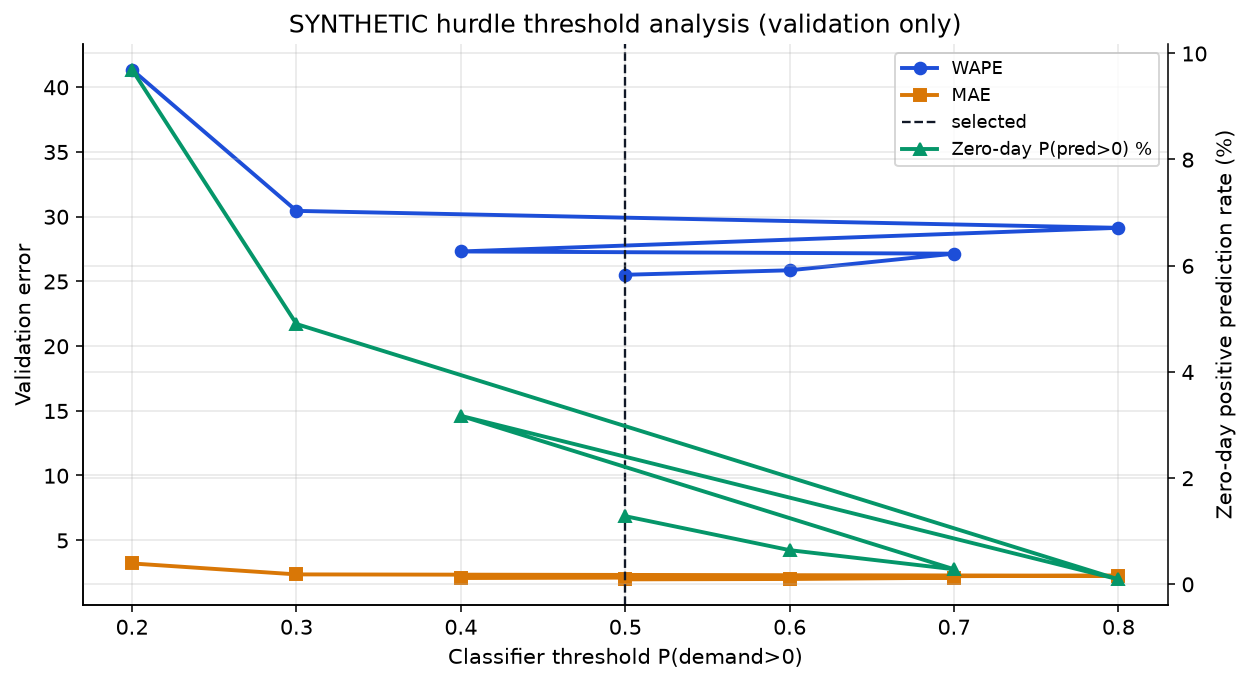

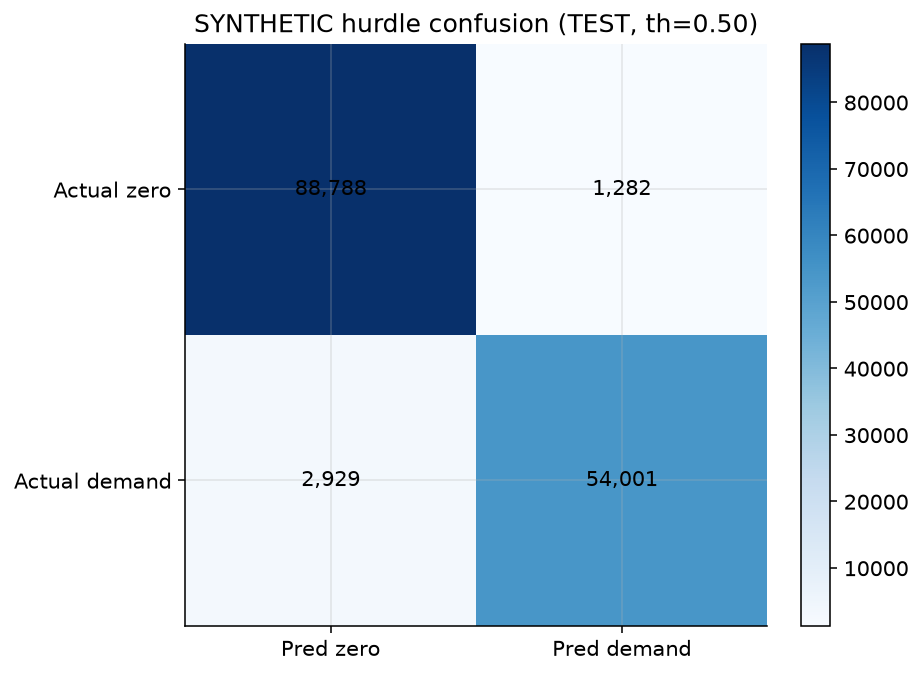

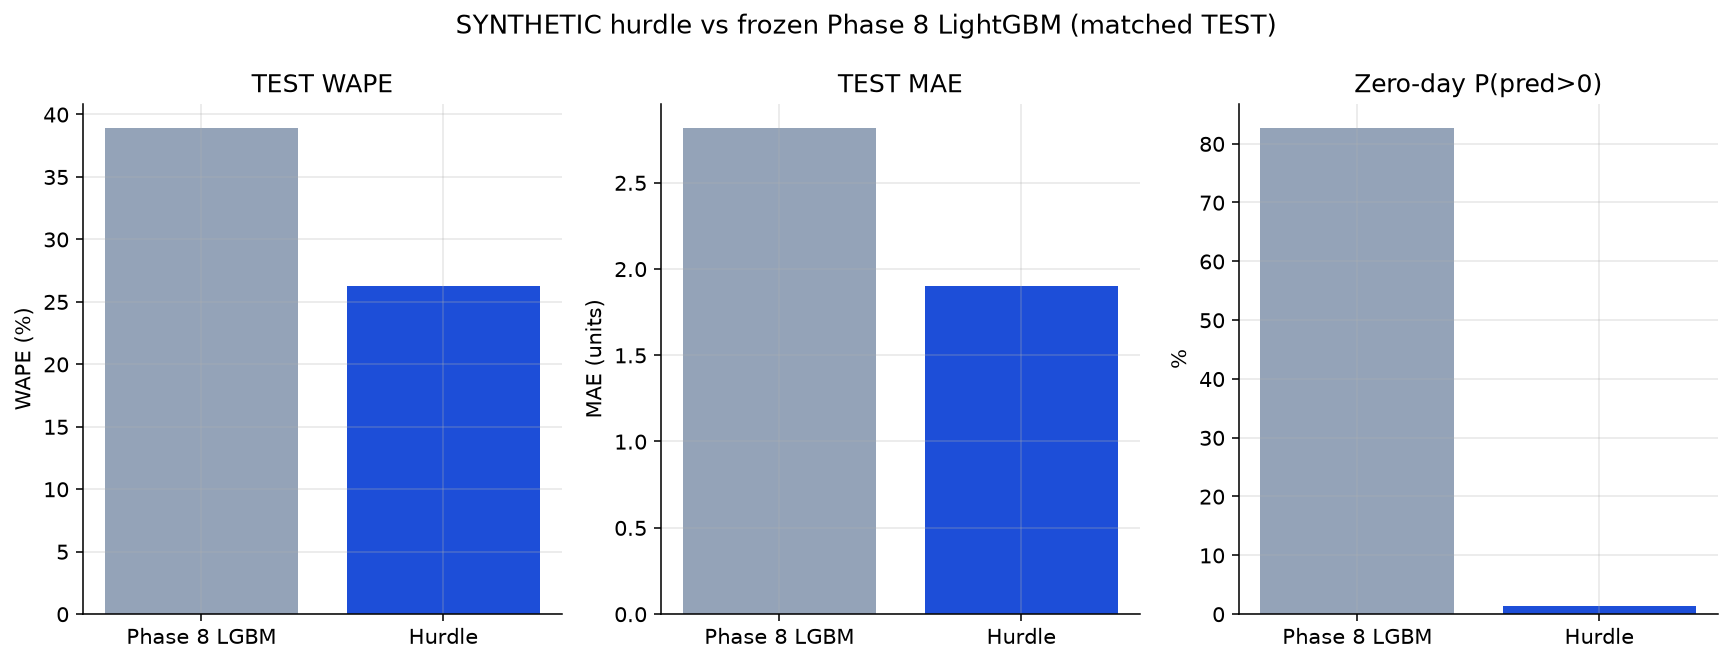

In [2]:
hv = pd.read_parquet(os.path.join(PHASE10_DIR, "hurdle_vs_phase8.parquet"))
print(hv.to_string(index=False))
thr = pd.read_parquet(os.path.join(PHASE10_DIR, "hurdle_threshold_table.parquet"))
print(thr.to_string(index=False))
display(Image(os.path.join(FIGURES_DIR, "zero_demand_threshold_analysis.png")))
display(Image(os.path.join(FIGURES_DIR, "classifier_confusion_matrix.png")))
display(Image(os.path.join(FIGURES_DIR, "hurdle_vs_lightgbm.png")))


## 3. Intermittent baselines

source_dataset   model  alpha  beta    MAE    RMSE    sMAPE     WAPE    bias      n  zero_mae  nonzero_mae  zero_positive_prediction_rate
     SYNTHETIC   naive    0.1   NaN 5.2717 10.4688  45.1750  72.8181 -0.0188 147000    1.7379      10.8625                          12.67
     SYNTHETIC croston    0.1   NaN 7.7901 10.4353 150.5177 107.6062  0.4565 147000    6.1796      10.3382                         100.00
     SYNTHETIC     sba    0.1   NaN 7.6817 10.3991 151.3849 106.1088  0.0717 147000    5.8706      10.5472                         100.00
     SYNTHETIC     tsb    0.1   0.1 7.4758 10.3056 151.0911 103.2639  0.1679 147000    5.6061      10.4339                         100.00


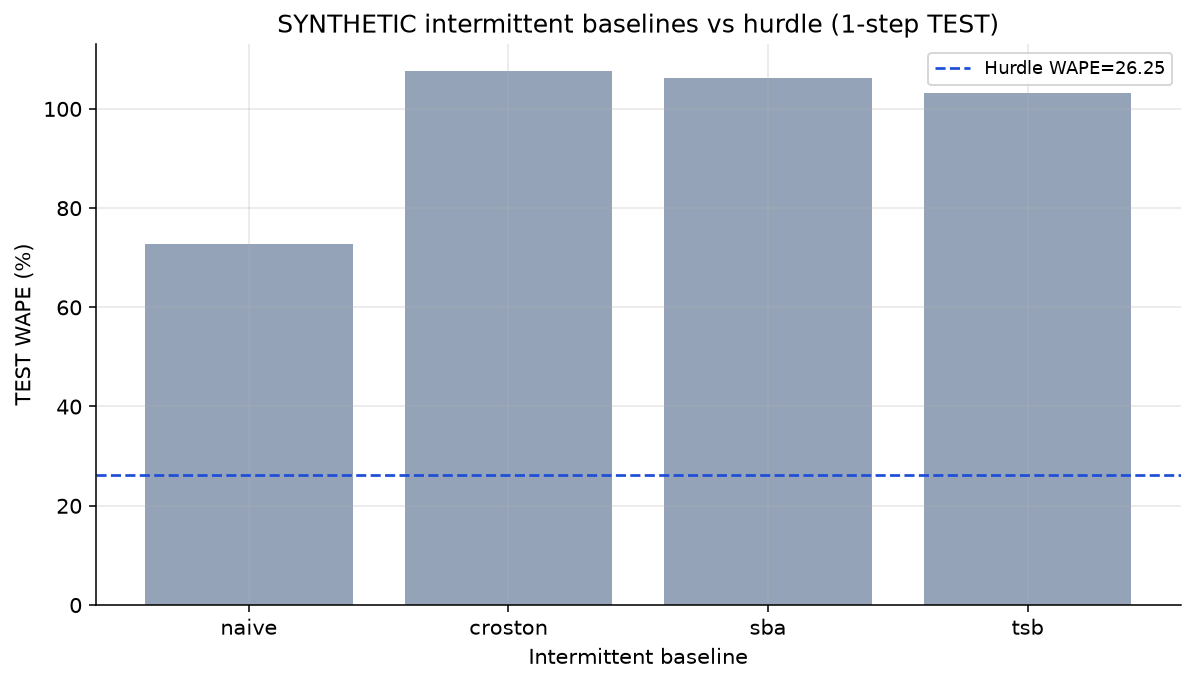

In [3]:
p = os.path.join(PHASE10_DIR, "intermittent_summary.parquet")
if os.path.exists(p):
    print(pd.read_parquet(p).to_string(index=False))
    display(Image(os.path.join(FIGURES_DIR, "intermittent_baseline_comparison.png")))
else:
    print("No intermittent summary (unexpected for SYNTHETIC)")


## 4. Direct vs recursive

source_dataset  horizon  recursive_WAPE  direct_WAPE  wape_improvement_pct  recursive_MAE  direct_MAE  recursive_sMAPE  direct_sMAPE  recursive_bias  direct_bias  direct_n  recursive_n                                                                                                                 note
           UCI        1         79.4761      84.9963               -6.9457        28.5693     18.8664          76.9311       87.4581         -2.4823      -0.2918     76377         4839 Populations differ: Phase 9 recursive used strided origins (UCI 400-series cap); direct uses all valid test origins.
           UCI        3         79.5917      85.1797               -7.0208        29.6548     19.3957          76.6289       88.0596         -1.6682      -0.5018     70571         4759 Populations differ: Phase 9 recursive used strided origins (UCI 400-series cap); direct uses all valid test origins.
           UCI        7         89.7171      86.1841                3.9379        33.9680     

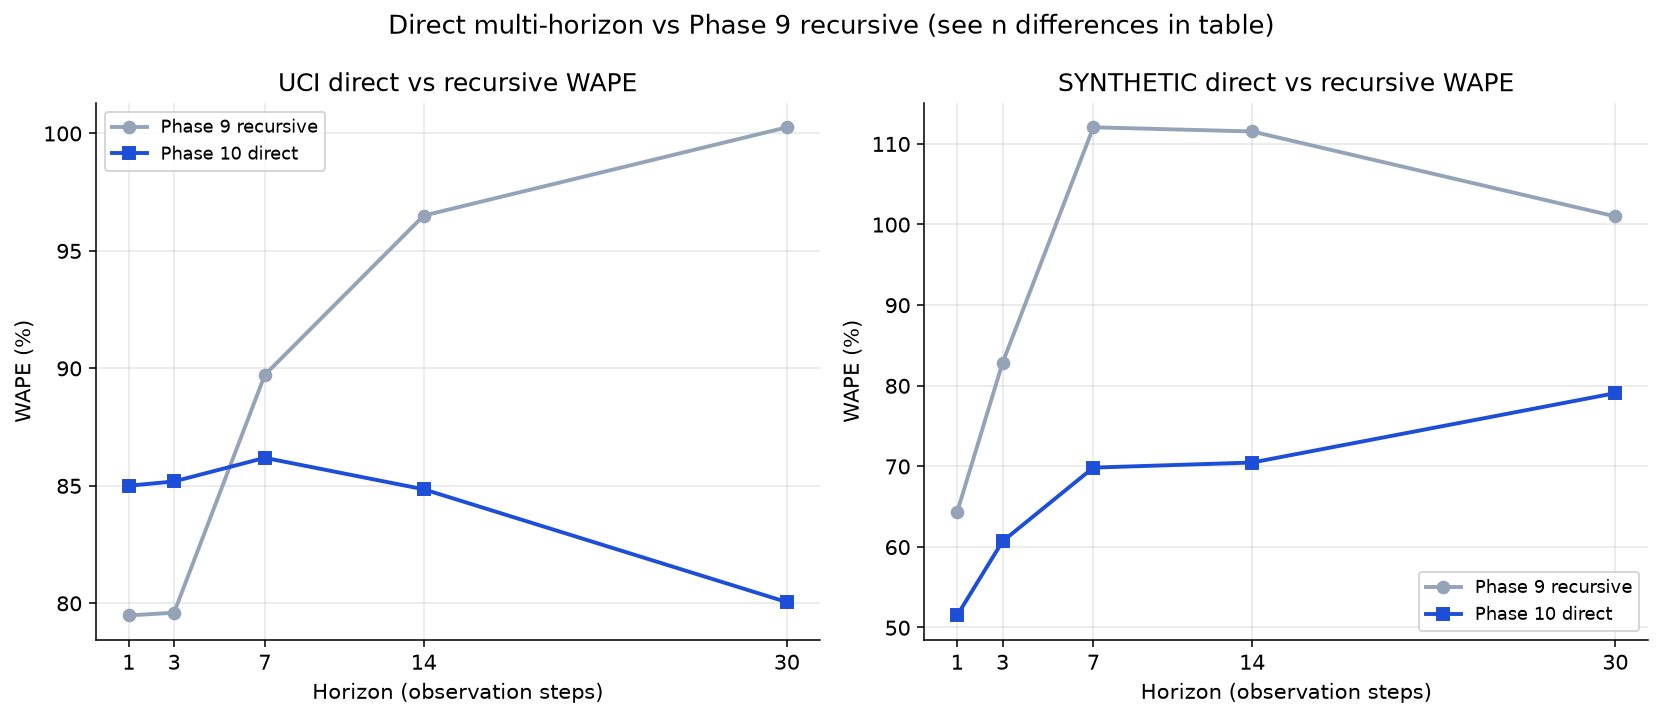

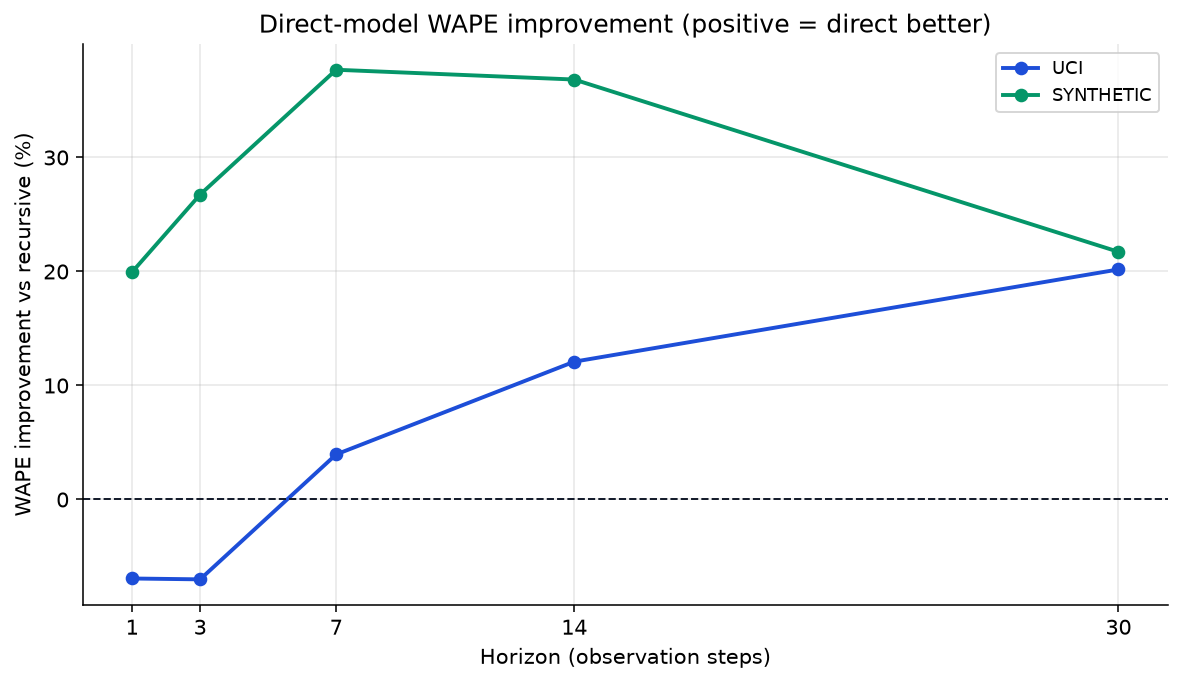

In [4]:
print(pd.read_parquet(os.path.join(PHASE10_DIR, "direct_vs_recursive.parquet")).to_string(index=False))
display(Image(os.path.join(FIGURES_DIR, "direct_vs_recursive_horizon.png")))
display(Image(os.path.join(FIGURES_DIR, "horizon_improvement.png")))


## 5. Prediction intervals

source_dataset  n_test  coverage_pct  mean_width  pinball_p10  pinball_p50  pinball_p90  p10_below_pct  p50_below_pct  p90_below_pct  n_crossed_before_reorder  n_negative_raw_p10  n_negative_raw_p50  n_negative_raw_p90  nonneg_clip  training_time_sec
           UCI   79545       82.3672     39.4081       2.0347       7.4040       6.3538          14.08          50.73          89.94                      1942                   0                 125                   6         True              8.332
     SYNTHETIC  147000       89.7673     10.0079       0.4652       1.2379       0.8975          64.04          78.77          93.80                      4264               25112                8201                2512         True             25.977


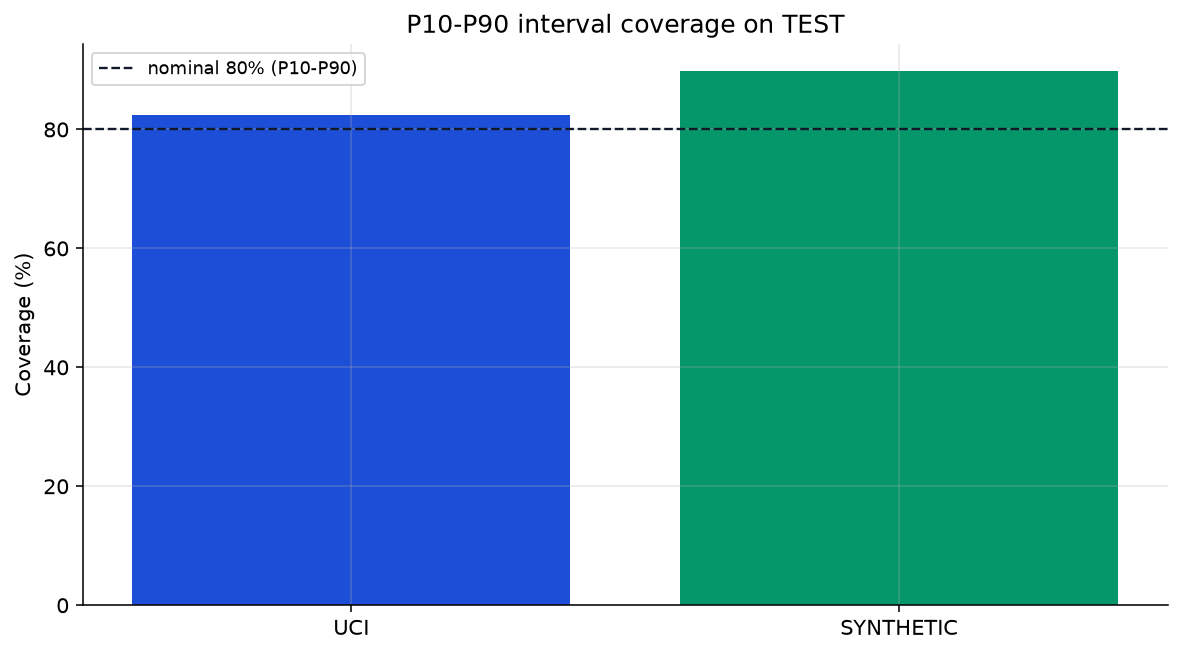

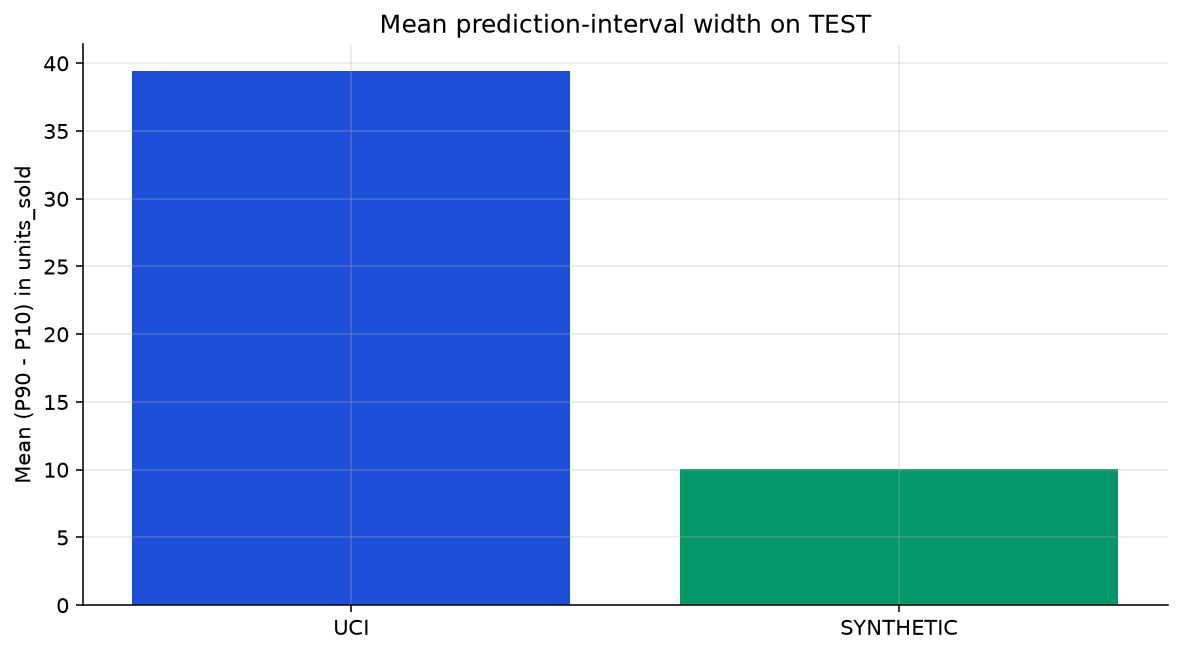

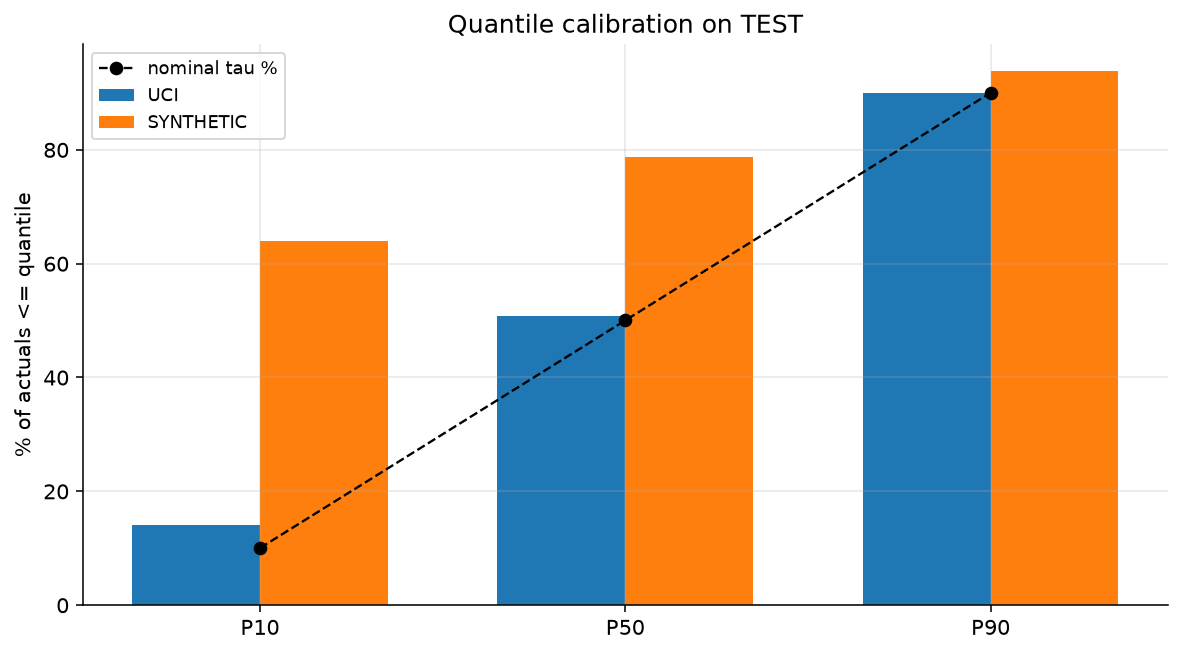

In [5]:
print(pd.read_parquet(os.path.join(PHASE10_DIR, "quantile_summary.parquet")).to_string(index=False))
display(Image(os.path.join(FIGURES_DIR, "prediction_interval_coverage.png")))
display(Image(os.path.join(FIGURES_DIR, "prediction_interval_width.png")))
display(Image(os.path.join(FIGURES_DIR, "quantile_calibration.png")))


## 6. HPO

source_dataset  config_id  is_phase8_config  num_leaves  learning_rate  n_estimators  min_child_samples  subsample  colsample_bytree  reg_alpha  reg_lambda  val_WAPE  val_MAE  val_RMSE  val_sMAPE  training_time_sec
           UCI          0              True          31           0.05           150                 20        0.8               0.8        0.0         0.0   76.9218  16.5035   55.8952    80.2343              1.407
           UCI          1             False          15           0.05           150                 20        0.8               0.8        0.0         0.0   80.3484  17.2387   57.3189    82.4433              1.171
           UCI          2             False          63           0.05           150                 20        0.8               0.8        0.0         0.0   75.4238  16.1821   55.8280    78.3387              2.378
           UCI          3             False          31           0.03           250                 20        0.8               0.8        

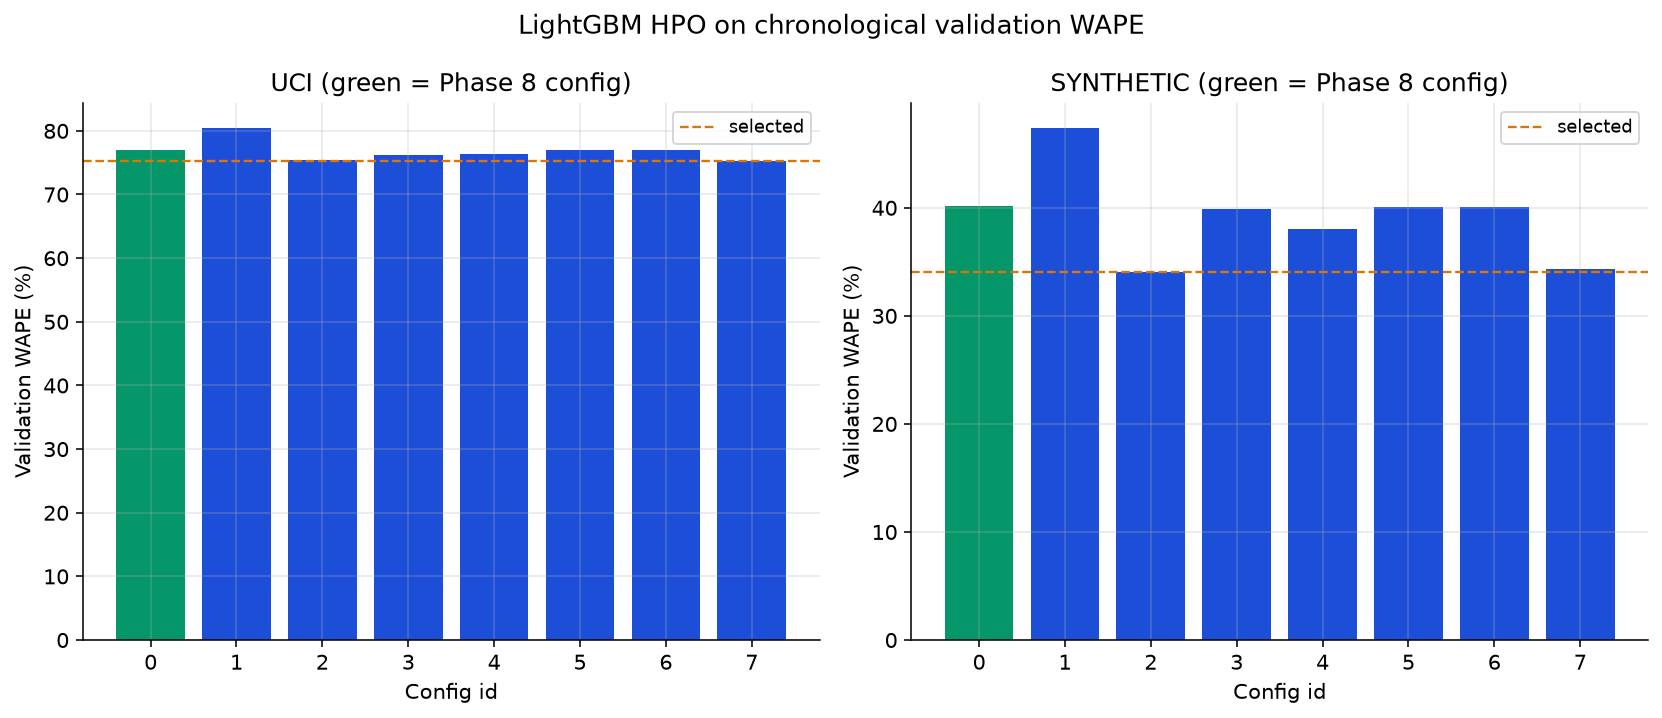

In [6]:
print(pd.read_parquet(os.path.join(PHASE10_DIR, "hpo_grid.parquet")).to_string(index=False))
print(pd.read_parquet(os.path.join(PHASE10_DIR, "hpo_summary.parquet")).to_string(index=False))
display(Image(os.path.join(FIGURES_DIR, "hyperparameter_comparison.png")))


## 7. Validation

In [7]:
result = run_validation()
print("VALIDATION", result.summary())
assert result.failed == 0
print("Phase 10 COMPLETE — STOP before Phase 11.")


PHASE 10 VALIDATION

[1] Freeze / data integrity
  [+] Phase 6 features exist
  [+] Phase 8 predictions exist
  [+] phase10_metadata.json exists
  [+] experiment registry exists
  [+] report exists
  [+] Phase 8 artifacts unchanged vs snapshot -- []
  [+] Phase 9 artifacts unchanged vs snapshot -- []
  [+] metadata.phase8_unchanged True
  [+] metadata.phase9_unchanged True


  [+] feature dates parse


  [+] no duplicate grain in features
  [+] split values expected

[2] Output artifacts
  [+] parquet hurdle_vs_phase8.parquet
  [+] parquet hurdle_threshold_table.parquet
  [+] parquet intermittent_summary.parquet
  [+] parquet direct_horizon_summary.parquet
  [+] parquet direct_vs_recursive.parquet
  [+] parquet direct_horizon_predictions.parquet
  [+] parquet quantile_summary.parquet
  [+] parquet quantile_predictions.parquet
  [+] parquet hpo_grid.parquet
  [+] parquet hpo_summary.parquet
  [+] figure zero_demand_threshold_analysis.png
  [+] figure classifier_confusion_matrix.png
  [+] figure hurdle_vs_lightgbm.png
  [+] figure intermittent_baseline_comparison.png
  [+] figure direct_vs_recursive_horizon.png
  [+] figure horizon_improvement.png
  [+] figure prediction_interval_coverage.png
  [+] figure prediction_interval_width.png
  [+] figure quantile_calibration.png
  [+] figure hyperparameter_comparison.png

[3] Hurdle leakage / construction
  [+] hurdle comparison has SYNTHETIC

  [+] no duplicate direct keys -- dup=0
  [+] h=1 sample nonempty

[5] Prediction intervals
  [+] quantile both sources
  [+] P10 <= P50
  [+] P50 <= P90
  [+] quantiles non-negative
  [+] interval width >= 0
  [+] coverage in 0-100
  [+] UCI coverage recomputes -- 82.3672 vs 82.3672
  [+] UCI pinball p50 finite
  [+] UCI pinball p50 matches
  [+] SYNTHETIC coverage recomputes -- 89.7673 vs 89.7673
  [+] SYNTHETIC pinball p50 finite
  [+] SYNTHETIC pinball p50 matches

[6] HPO time-aware
  [+] HPO has Phase 8 config candidate
  [+] HPO both sources
  [+] HPO val WAPE finite
  [+] UCI HPO selected by val WAPE -- 7 vs 7
  [+] SYNTHETIC HPO selected by val WAPE -- 2 vs 2

[7] Metrics / Phase 8 reference
  [+] Phase 8 SYNTHETIC WAPE reference
  [+] WAPE non-negative where present

[8] Registry / metadata
  [+] registry is a list
  [+] registry experiment_id unique
  [+] registry has hurdle experiment
  [+] registry has direct experiment
  [+] metadata.python_version
  [+] metadata.random_s